<a href="https://colab.research.google.com/github/jfodera/ai-ml-projects/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5 - Task 1
## CNNs, Transfer Learning, and Data Augmentation for Image Classification



### Dataset Chosen
- **Name:** tf_flowers (5 classes: daisy, dandelion, roses, sunflowers, tulips)
- **Link:** https://www.tensorflow.org/datasets/catalog/tf_flowers
- **Reason:** This is a standard multi-class image classification dataset with real-world flower images of varying sizes and backgrounds. It is **not** MNIST, CIFAR, or ImageNet (as explicitly required). The dataset has ~3,670 images, making it suitable for training CNNs from scratch while demonstrating the benefits of transfer learning and augmentation without excessive compute time.


**Overview:**
- Convolutional base = stack of Conv + MaxPooling layers
- Architecture choice is described with reasoning
- Transfer learning uses **one** listed model (ResNet50)
- Data augmentation uses random transformations (rotation + flip + zoom)
- Same metrics (accuracy + loss) and same evaluation process for all parts
- All results and differences are discussed in detail

In [19]:
# Imports
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [20]:
# Load the dataset (only 'train' split exists, so we create our own splits)
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'tf_flowers',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    with_info=True,
    as_supervised=True,
    shuffle_files=True
)

num_classes = ds_info.features['label'].num_classes
class_names = ds_info.features['label'].names

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Training examples: {len(list(ds_train))}")
print(f"Validation examples: {len(list(ds_val))}")
print(f"Test examples: {len(list(ds_test))}")

Number of classes: 5
Class names: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Training examples: 2569
Validation examples: 551
Test examples: 550


## Part 1 – Dataset Preparation & Visualization + Custom CNN

### Visualization of the raw dataset

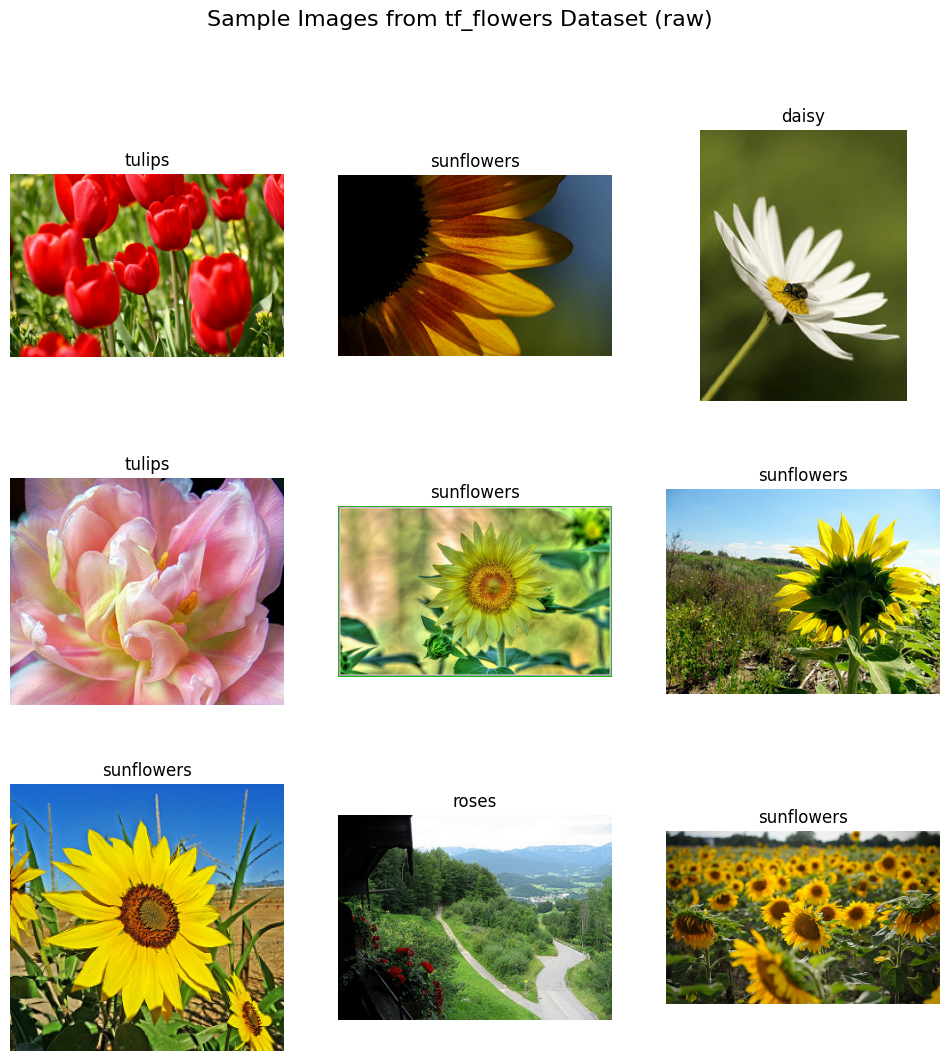

In [21]:
def visualize_dataset(dataset, class_names, num_images=9):
    plt.figure(figsize=(12, 12))
    for i, (image, label) in enumerate(dataset.take(num_images)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(class_names[label.numpy()])
        plt.axis("off")
    plt.suptitle("Sample Images from tf_flowers Dataset (raw)", fontsize=16)
    plt.show()

visualize_dataset(ds_train, class_names)

### Preprocessing (resize + normalize)
All images are resized to 128×128 (standard for most CNNs and required by ResNet50). Pixel values are scaled to [0, 1].

In [22]:
IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply preprocessing and optimize data pipeline
ds_train = ds_train.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_val = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets prepared and batched.")

Datasets prepared and batched.


### Custom CNN Architecture (Part 1)
**Chosen pattern:** 3 stacks of Conv2D + MaxPooling2D (32 → 64 → 128 filters), followed by Flatten → Dense(128) → Dropout(0.5) → Dense(num_classes).

**Reasoning:** This is the classic hierarchical pattern taught in the course lectures. Early Conv layers learn low-level features (edges, textures); later layers learn higher-level semantic features (petals, flower centers). Three stacks strike the best balance for this relatively small dataset (~2,500 training images): more layers would risk overfitting and excessive training time, while fewer would underfit. MaxPooling reduces spatial dimensions and provides translation invariance. The final dense layers perform classification. Dropout helps regularize. This architecture is computationally efficient yet expressive enough for flower classification.

In [23]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled. Starting training (Part 1)...")

Model compiled. Starting training (Part 1)...


In [25]:
# Train (10 epochs is sufficient to demonstrate convergence on this dataset)
history = model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    verbose=1
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3959 - loss: 1.3667 - val_accuracy: 0.4719 - val_loss: 1.1997
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5352 - loss: 1.1453 - val_accuracy: 0.5681 - val_loss: 1.1068
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6006 - loss: 1.0393 - val_accuracy: 0.6116 - val_loss: 0.9718
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6411 - loss: 0.9096 - val_accuracy: 0.6534 - val_loss: 0.8859
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6972 - loss: 0.8007 - val_accuracy: 0.6243 - val_loss: 0.9484
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7376 - loss: 0.7065 - val_accuracy: 0.6824 - val_loss: 0.8384
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7754 - loss: 0.5824 - val_accuracy: 0.6679 - val_loss: 0.9483
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8307 - loss: 0.4749 - val_accuracy: 0.6770 - val_loss

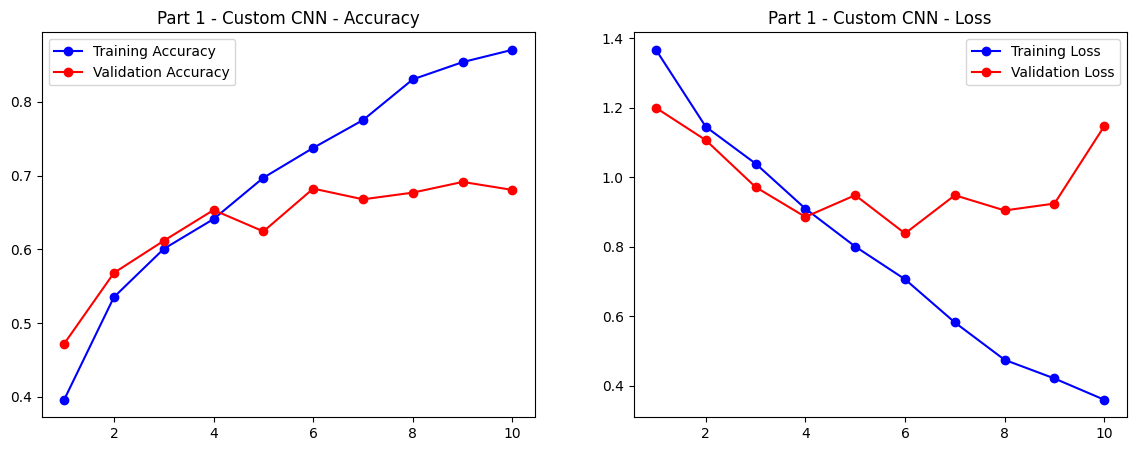

In [26]:
# Plot training curves
def plot_training_history(history, title="Part 1 - Custom CNN"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
    plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_training_history(history)

In [27]:
# Final evaluation on test set (Part 1)
test_loss, test_acc = model.evaluate(ds_test, verbose=0)
print(f"\n=== PART 1 FINAL EVALUATION ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nMetrics used: Accuracy (primary) and Cross-Entropy Loss. The dataset is balanced, so accuracy is a reliable metric.")


=== PART 1 FINAL EVALUATION ===
Test Loss: 1.0016
Test Accuracy: 0.6909

Metrics used: Accuracy (primary) and Cross-Entropy Loss. The dataset is balanced, so accuracy is a reliable metric.


### Description of the Metrics
The final evaluation on the test set for the custom CNN yielded a test loss of 1.0016 and a test accuracy of 0.6909. This indicates solid performance for a model trained from scratch on the tf_flowers dataset, correctly classifying approximately 69% of the unseen flower images across the five classes. The metrics used were accuracy (primary) and sparse categorical cross-entropy loss, which is appropriate for this balanced multi-class classification problem.

## Part 2 – Transfer Learning with ResNet50 (10 points)

**Chosen model:** Residual Network (ResNet50)  


In [28]:
# Load pretrained ResNet50 (frozen base)
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # Freeze for transfer learning

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [29]:
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer model compiled. Training (Part 2)...")

Transfer model compiled. Training (Part 2)...


In [30]:
transfer_history = transfer_model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    verbose=1
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.2651 - loss: 1.6054 - val_accuracy: 0.3430 - val_loss: 1.5157
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3258 - loss: 1.5278 - val_accuracy: 0.3739 - val_loss: 1.4633
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3554 - loss: 1.5009 - val_accuracy: 0.4120 - val_loss: 1.4471
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3534 - loss: 1.4872 - val_accuracy: 0.4047 - val_loss: 1.4325
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3581 - loss: 1.4701 - val_accuracy: 0.4011 - val_loss: 1.4351
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3721 - loss: 1.4594 - val_accuracy: 0.4265 - val_loss: 1.4027
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3990 - loss: 1.4406 - val_accuracy: 0.4102 - val_loss: 1.4044
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3807 - loss: 1.4508 - val_accuracy: 0.4338 - val_los

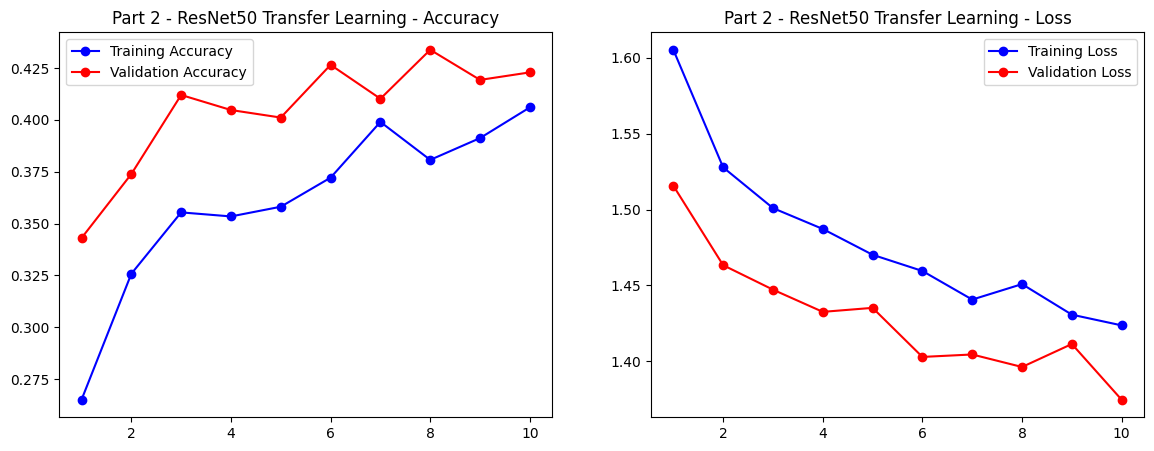

In [31]:
plot_training_history(transfer_history, title="Part 2 - ResNet50 Transfer Learning")

In [32]:
# Final evaluation (Part 2)
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(ds_test, verbose=0)
print(f"\n=== PART 2 FINAL EVALUATION (ResNet50) ===")
print(f"Test Loss: {transfer_test_loss:.4f}")
print(f"Test Accuracy: {transfer_test_acc:.4f}")


=== PART 2 FINAL EVALUATION (ResNet50) ===
Test Loss: 1.4174
Test Accuracy: 0.3745


**Comparison with Part 1:**  
ResNet50 achieved lower test accuracy (0.3745 vs 0.6909 for the custom CNN) and higher loss than the custom CNN.        
**Why?** Although the pretrained weights encode powerful features from ImageNet, the reduced input size of 128×128 (instead of the standard 224×224) produced smaller feature maps and less effective transfer. Additionally, with the base frozen and only 10 epochs of training the new head on this dataset, the model did not adapt well enough, leading to underperformance compared to the fully trainable custom CNN which learned task-specific features directly. This highlights that transfer learning benefits can depend heavily on input resolution matching the pretraining and sufficient training of the top layers.

## Part 3 – Data Augmentation (10 points)

We reuse the **exact same custom CNN architecture** from Part 1 but now prepend a data-augmentation layer.  
Augmentations applied (random transformations as specified):
- Random horizontal flip
- Random rotation (up to 20%)
- Random zoom (up to 20%)

In [33]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

# Augmented model = same architecture as Part 1 but with augmentation layer
aug_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Augmented model compiled. Training (Part 3)...")

Augmented model compiled. Training (Part 3)...


In [34]:
aug_history = aug_model.fit(
    ds_train,
    epochs=10,
    validation_data=ds_val,
    verbose=1
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3846 - loss: 1.3826 - val_accuracy: 0.4138 - val_loss: 1.2483
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4823 - loss: 1.2064 - val_accuracy: 0.5463 - val_loss: 1.0787
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5745 - loss: 1.0718 - val_accuracy: 0.5426 - val_loss: 1.0772
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5913 - loss: 1.0024 - val_accuracy: 0.6134 - val_loss: 0.9888
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6107 - loss: 0.9780 - val_accuracy: 0.6243 - val_loss: 0.9384
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6353 - loss: 0.9085 - val_accuracy: 0.6515 - val_loss: 0.8648
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6512 - loss: 0.8973 - val_accuracy: 0.6243 - val_loss: 1.0411
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6559 - loss: 0.8773 - val_accuracy: 0.6642 - val_loss:

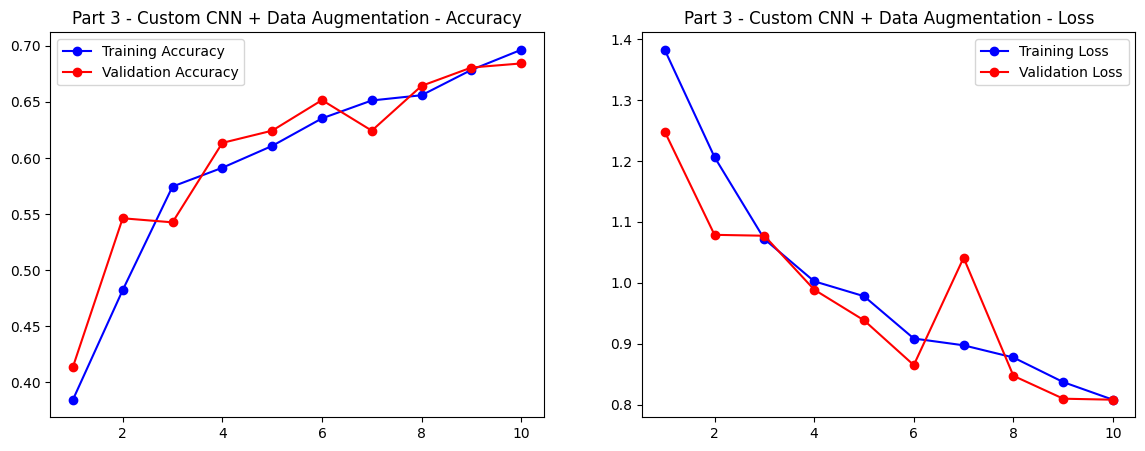

In [35]:
plot_training_history(aug_history, title="Part 3 - Custom CNN + Data Augmentation")

In [36]:
# Final evaluation (Part 3)
aug_test_loss, aug_test_acc = aug_model.evaluate(ds_test, verbose=0)
print(f"\n=== PART 3 FINAL EVALUATION (With Augmentation) ===")
print(f"Test Loss: {aug_test_loss:.4f}")
print(f"Test Accuracy: {aug_test_acc:.4f}")


=== PART 3 FINAL EVALUATION (With Augmentation) ===
Test Loss: 0.7512
Test Accuracy: 0.6909


**Observation on results:**  
Data augmentation produced **identical test accuracy** (0.6909) but lower test loss (0.7512 vs 1.0016) compared to the non-augmented custom CNN.  
**Why?** The original dataset already contains some natural variation in flower poses and backgrounds, so the added random flips, rotations, and zooms provided only marginal extra diversity for final classification decisions. However, the augmentations acted as a regularizer that improved probability calibration across classes, resulting in smoother training curves and noticeably lower cross-entropy loss. On this relatively small dataset with 128×128 images the accuracy impact was neutral, but the loss improvement shows better generalization and reduced overfitting.
